## MARS-S2L — automatic background image selection [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UNEP-IMEO-MARS/marss2l/blob/main/notebooks/examples/background_image_selection.ipynb)

* **Author**: MARS team
---

## Overview

The MBMP retrieval compares a *target* Sentinel-2/Landsat overpass against a clear-sky **background image** of the same location from a different date. Picking a good background — same location, cloud-free, spectrally similar to the target — is what makes the retrieval clean.

This notebook shows how `BackgroundImageSelector` finds that background **directly from Google Earth Engine** (no database). It:

1. builds a target image from a known tile,
2. queries GEE for candidate backgrounds and filters them locally (cloud masks computed on the fly),
3. ranks the candidates by similarity and shows the **top-X most similar** backgrounds,
4. uses the best one to run the MBMP retrieval and the methane concentration ($\Delta$XCH$_4$) image.

This replaces the hand-picked `background_image_tile` used in `download_and_inference.ipynb` with a computed, explainable choice.

### Install `marss2l`

```bash
pip install marss2l
```

## 1. Initialize GEE

In [1]:
from marss2l.mars_sentinel2 import ee as ee_utils
import ee
from marss2l.utils import setup_stream_logger

# Set your Google Earth Engine project id here. Leave it empty ("") to fall back
# to the GEE_PROJECT environment variable if it is configured.
gee_project = ""
ee_utils.ee_initialize(project=gee_project)


logger = setup_stream_logger()

/home/gonzalo/mambaforge/envs/marss2lpy312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using service account for EE


## 2. Build the target image

We start from a known location and a target scene (the same Sentinel-2 example as `download_and_inference.ipynb`). `Location` mirrors the marsml monitoring-site object; `S2LLocationImage` mirrors `MarsLocationImage`.

In [2]:
from marss2l.mars_sentinel2.location_image import Location, S2LLocationImage
from marss2l.mars_sentinel2.background import BackgroundImageSelector

lat, lon = 32.16492, -102.13013
tile = "S2B_MSIL1C_20250529T172859_N0511_R055_T13SGR_20250529T210525"

location = Location.from_lon_lat(lon=lon, lat=lat, margin_meters=2000, location_name="example")
target = S2LLocationImage.from_tile(tile, location=location, logger=logger)
target.tile, target.satellite, target.tile_date

('S2B_MSIL1C_20250529T172859_N0511_R055_T13SGR_20250529T210525',
 'S2B',
 datetime.datetime(2025, 5, 29, 17, 45, 4, 194000, tzinfo=datetime.timezone.utc))

## 3. Create the selector and download the target pixels

In [3]:
selector = BackgroundImageSelector(method_bg_image="most_similar", logger=logger)
selector.download_image(target)
print(f"target percentage_clear = {target.percentage_clear:.1f}%  observability = {target.observability}")

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


target percentage_clear = 100.0%  observability = clear


> **Caveat — plumes in background images.** In the full MARS pipeline, candidate backgrounds that *contain a methane plume blowing in a wind direction similar to the target's* are deliberately excluded: such a plume would contaminate the reference scene and bias the retrieval low. That exclusion relies on plume labels and per-image wind stored in the MARS database, which are **not available from Google Earth Engine alone** — so in this GEE-only example the wind-aligned-plume filter is inactive, and a selected background could in principle contain an unlabelled plume. Visually inspecting the top candidates (section 5) is the practical safeguard here.

## 4. Find the top-5 most similar background candidates

`query_background_images` queries GEE, downloads the cloud mask for a bounded set of candidates (so it can filter on the locally computed cloud fraction), and returns them **already filtered and sorted** — it applies the cloud / satellite / orbit / date filters internally. `background_images_most_similar_sorted` then ranks the survivors by spectral similarity to the target.

In [ ]:
candidates = selector.query_background_images(target)  # already filtered and sorted
ranked = selector.background_images_most_similar_sorted(target, candidates, top=5)

for bg, difference in ranked:
    print(f"{bg.satellite} {bg.day}  difference = {difference * 100:.2f}%")

## 5. Plot RGB | difference | MBMP, sorted from most to least similar

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


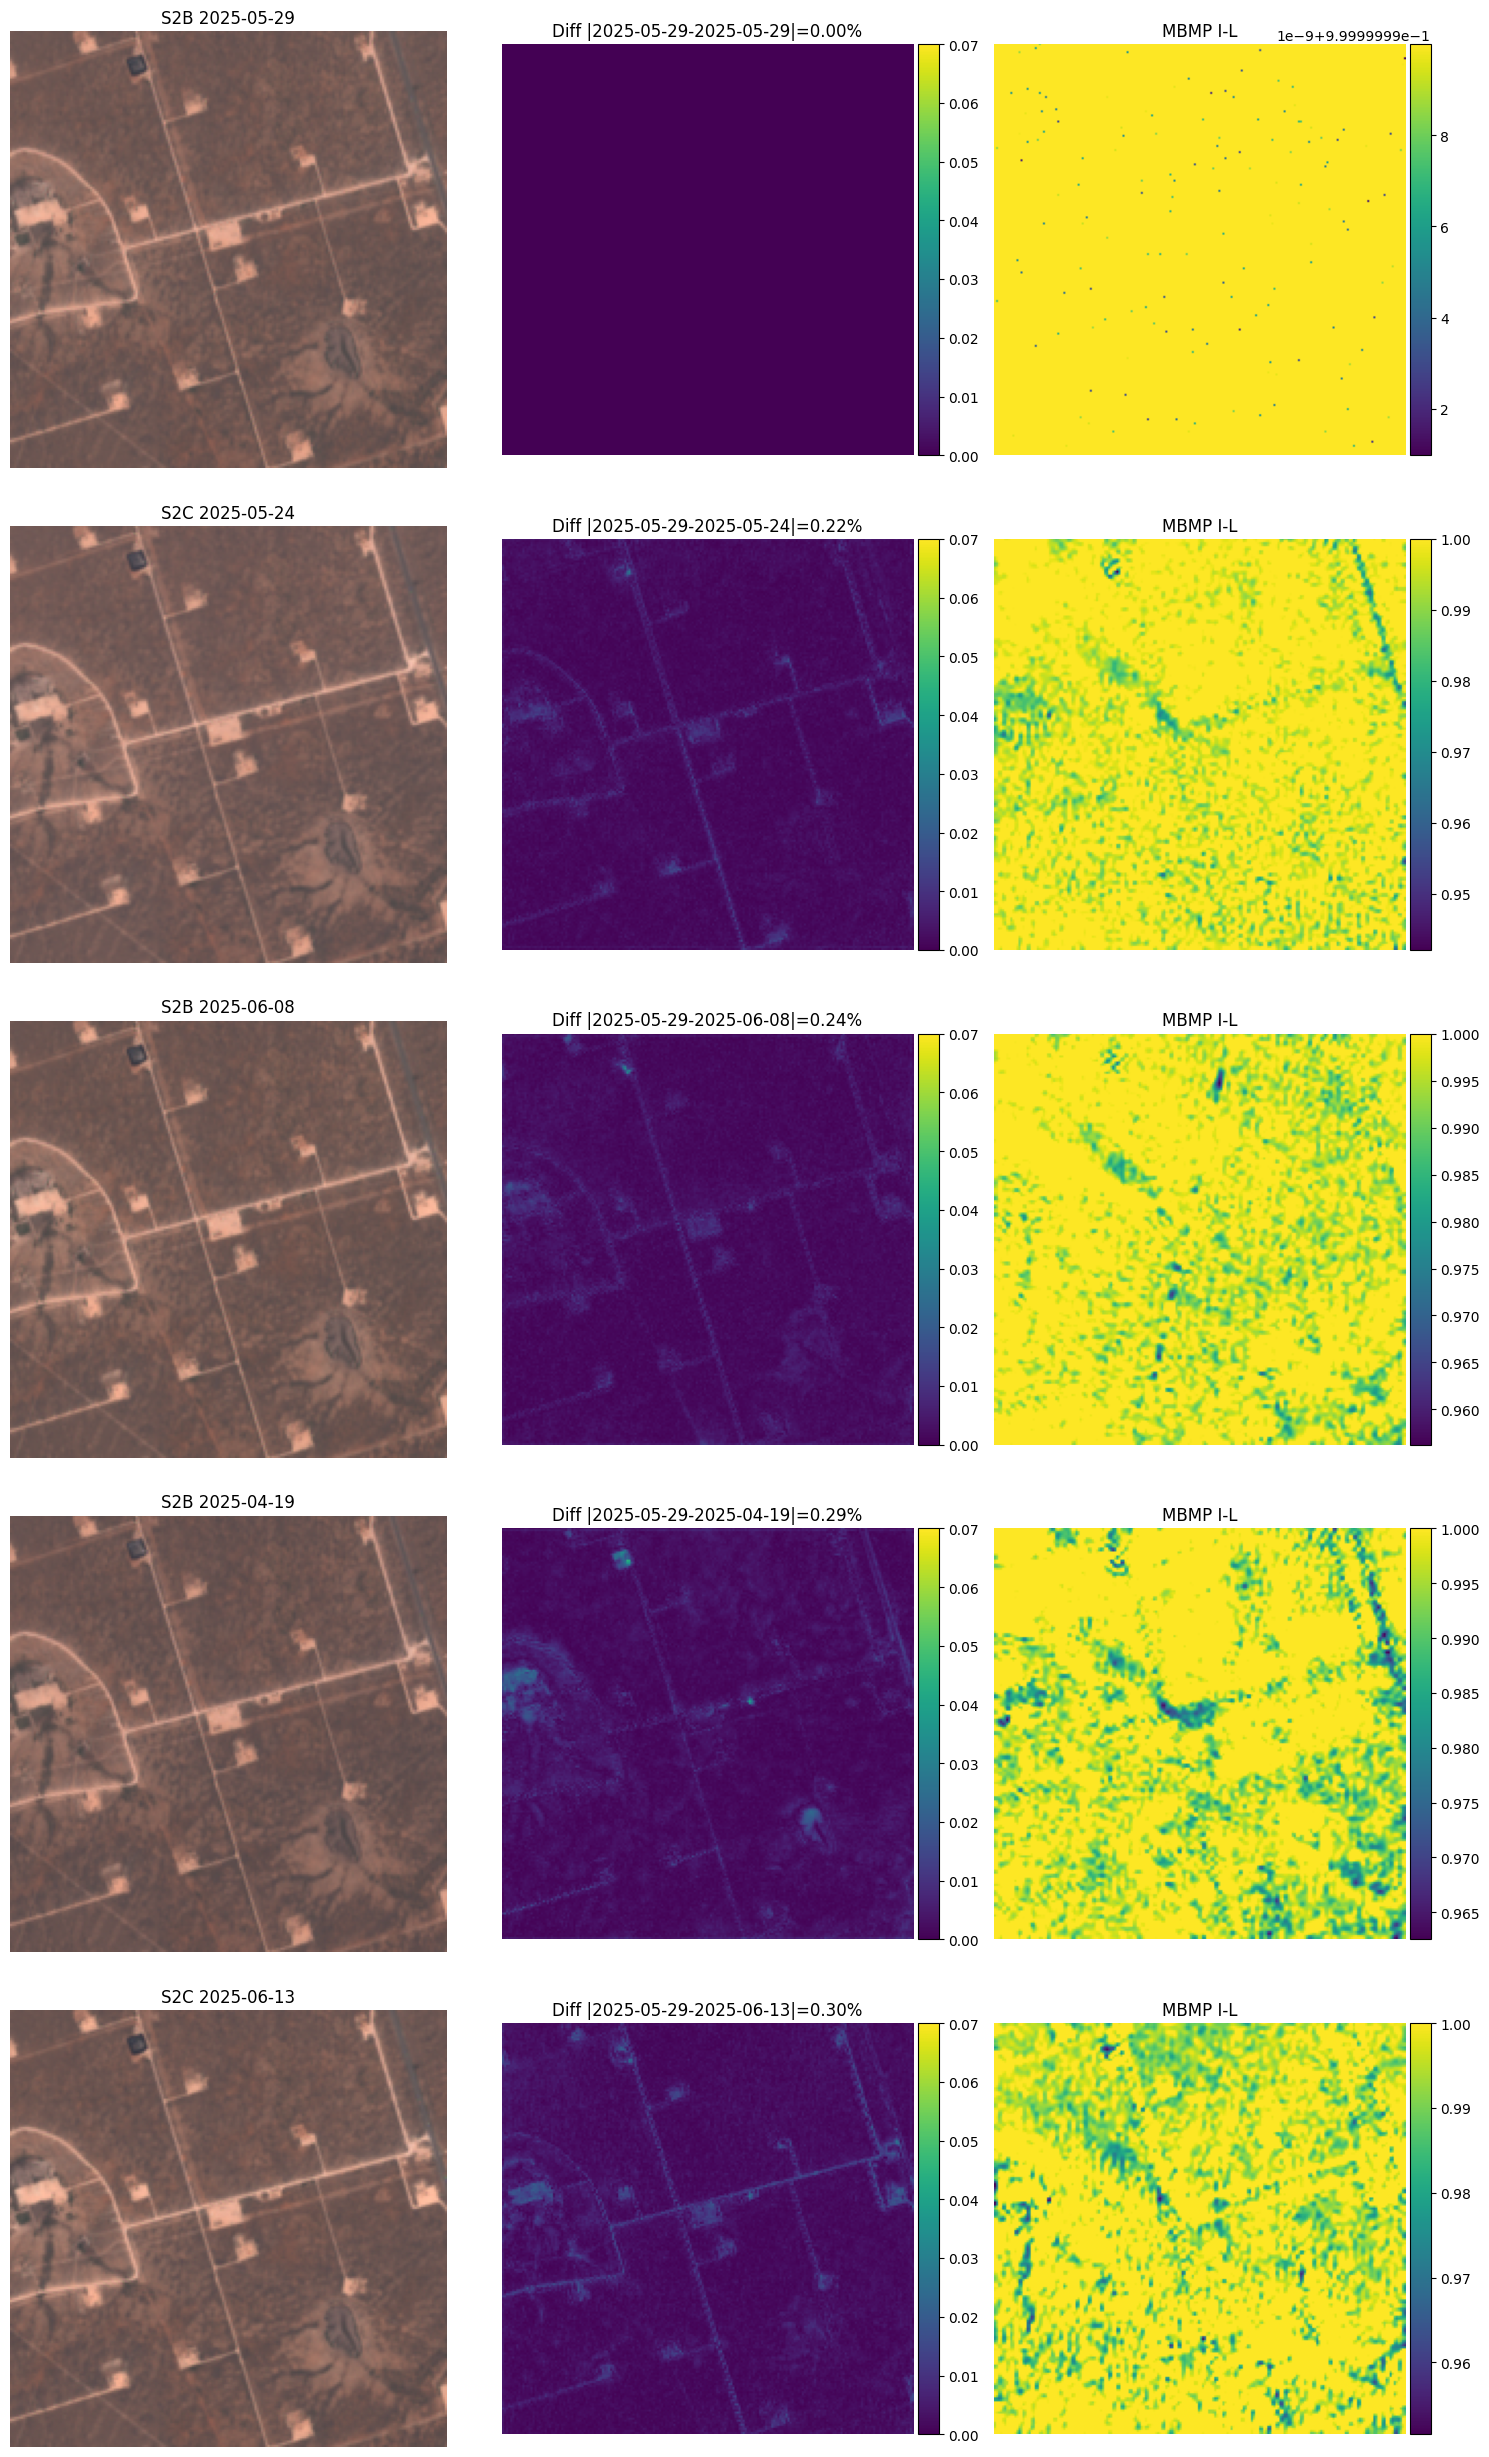

In [5]:
fig = selector.plot_all_differences(target, ranked)

## 6. Use the best background

The most similar candidate is `ranked[0][0]` (equivalently `selector.compute_background_image(target)`). We download the target's wind and plot the target and selected background side by side.

File GEOS.fp.asm.tavg1_2d_slv_Nx.20250529_1730.V01.nc4 exists. It won't be downloaded again


<Axes: title={'center': 'background S2B 2025-05-29'}>

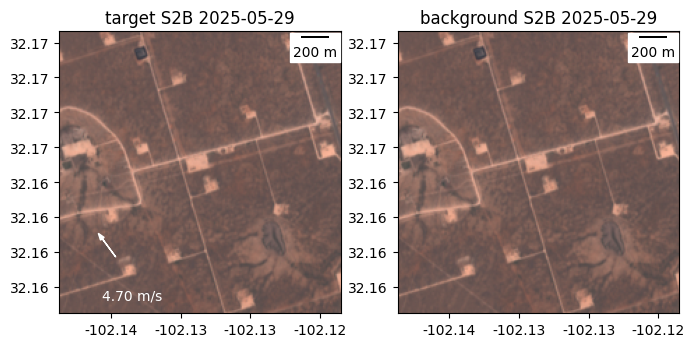

In [6]:
from georeader import plot
import matplotlib.pyplot as plt
from marss2l.mars_sentinel2 import wind

background = ranked[0][0]
selector.download_image(background)

windu, windv = wind.download_wind_nasa_geos_fp((lon, lat), target.tile_date)

rgb_idx = [selector.band_index(target, b) for b in ("B04", "B03", "B02")]
rgb = (target.image.isel({"band": rgb_idx}) / 4_500).clip(0, 1)
rgb_bg = (background.image.isel({"band": rgb_idx}) / 4_500).clip(0, 1)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
plot.show(rgb, ax=ax[0], title=f"target {target.satellite} {target.day}", add_scalebar=True)
wind.add_wind_to_plot([windu, windv], ax=ax[0])
plot.show(rgb_bg, ax=ax[1], title=f"background {background.satellite} {background.day}", add_scalebar=True)

## 7. Compute the MBMP retrieval

Following [Irakulis-Loitxate et al., 2022](https://doi.org/10.1021/acs.est.1c04873), the MBMP ratio compares the target against the cloud-free background in the methane-sensitive SWIR bands; lower values indicate a stronger methane signal.

<Axes: title={'center': 'MBMP retrieval'}>

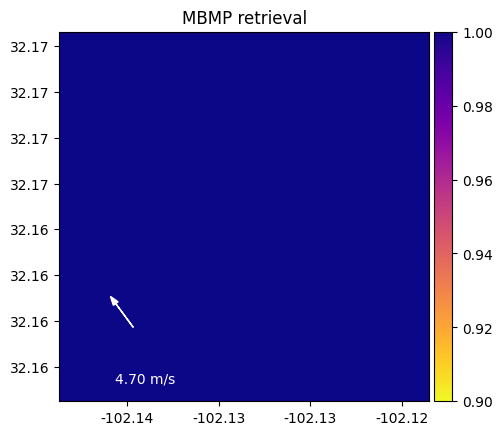

In [7]:
from marss2l.mars_sentinel2 import mixing_ratio_methane

validmask = selector.validmask(target)
mbmp = mixing_ratio_methane.ratio_IL(
    target.image,
    background.image,
    b11_index=selector.band_index(target, "B11"),
    b12_index=selector.band_index(target, "B12"),
    b11_index_bg=selector.band_index(background, "B11"),
    b12_index_bg=selector.band_index(background, "B12"),
    fill_value_ratio_il=1,
    validmask=validmask,
    validmask_bg=selector.validmask(background),
    corregister=True,
)

ax = plot.show(mbmp, vmin=0.9, vmax=1, cmap="plasma_r", add_colorbar_next_to=True, title="MBMP retrieval")
wind.add_wind_to_plot([windu, windv], ax=ax)

## 8. Compute the methane concentration image $\Delta\text{XCH}_4$

The MBMP ratio is converted to a methane enhancement (ppb) with the per-satellite transmittance look-up table, using the target's solar and view zenith angles.

<Axes: title={'center': '$\\Delta$XCH$_4$ (ppb)'}>

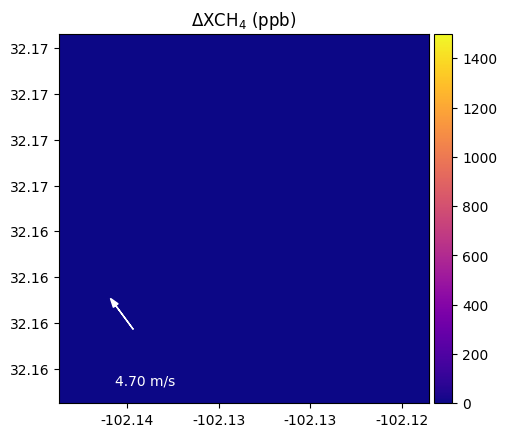

In [8]:
from marss2l.mars_sentinel2 import transmittance_to_ch4

ch42tr = transmittance_to_ch4.TransmittanceCH4InterpolationFromDict()
ch4 = ch42tr.deltach4_from_ratio_transmittance(
    satellite=target.satellite, sza=target.sza, vza=target.vza, ratio_il=mbmp
)

ax = plot.show(ch4, vmin=0, vmax=1_500, cmap="plasma", add_colorbar_next_to=True, title=r"$\Delta$XCH$_4$ (ppb)")
wind.add_wind_to_plot([windu, windv], ax=ax)

## Licence
The `marss2l` package is published under a [GNU Lesser GPL v3 licence](https://www.gnu.org/licenses/lgpl-3.0.en.html).

`marss2l` tutorials and notebooks are released under a [Creative Commons non-commercial share-alike licence](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.txt).